<a href="https://colab.research.google.com/github/YatzyOmg/Particle-Physics/blob/main/Reconstrucci%C3%B3n_de_la_masa_invariante_de_un_par_de_muones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo de masa invariante de una base de datos de colisiones
Empezamos importando las librerias importantes que se utilizan en este analísis de datos tales como son pandas, numpy y matplotlib para las gráficas. Posteriormente se añade a la variable ´´url´´ el link de esta base de datos en formato csv para luego leerlo con pandas, finalmente se imprime información importante para nuestro análisis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://opendata.cern.ch/record/5208/files/Zmumu.csv"
df = pd.read_csv(url)
df.head()

,Run,Event,pt1,eta1,phi1,Q1,dxy1,iso1,pt2,eta2,phi2,Q2,dxy2,iso2
0,165617,74969122,54.7055,-0.4324,2.5742,1,-0.0745,0.4999,34.2464,-0.9885,-0.4987,-1,0.0712,3.4221
1,165617,75138253,24.5872,-2.0522,2.8666,-1,-0.0554,0.0000,28.5389,0.3852,-1.9912,1,0.0515,0.0000
2,165617,75887636,31.7386,-2.2595,-1.3323,-1,0.0879,0.0000,30.2344,-0.4684,1.8833,1,-0.0876,0.0000
3,165617,75779415,39.7394,-0.7123,-0.3123,1,0.0585,0.0000,48.2790,-0.1956,2.9703,-1,-0.0492,0.0000
4,165617,75098104,41.2998,-0.1571,-3.0408,1,-0.0305,1.2280,43.4508,0.5910,-0.0428,-1,0.0442,0.0000


In [7]:
df.shape

(10000, 14)

Es importante convertir las variables numéricas del conjunto de datos a un formato numérico antes de realizar los cálculos. Al leer un archivo CSV, algunas variables pueden ser interpretadas por Pandas como cadenas de texto (str), como el momento transversal (pt), la pseudorapidez (eta) y el ángulo azimutal (phi) de ambos muones. El ciclo for permite aplicar la conversión a cada columna de manera automática. Además, errors="coerce" hace que cualquier valor que no pueda convertirse en número sea reemplazado por NaN, evitando que el programa se detenga por un dato incorrecto.

In [8]:
# Convertir las variables numéricas a tipo float
columnas_numericas = [
    "pt1", "eta1", "phi1", "Q1", "dxy1", "iso1",
    "pt2", "eta2", "phi2", "Q2", "dxy2", "iso2"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

Para reconstruir la masa invariante del par de muones, primero se calculan las diferencias entre sus valores de pseudorapidez (eta) y de ángulo azimutal (phi). Estas diferencias permiten describir la separación angular entre los dos muones.

En el caso de delta_phi, se realiza una transformación para mantener su valor dentro del intervalo ([-\pi,\pi]). Esto es necesario porque el ángulo azimutal es periódico y una diferencia directa entre dos ángulos puede producir valores fuera de este intervalo.

Posteriormente, se calcula la masa invariante del sistema de los dos muones.

In [9]:
# Diferencias de eta y phi
delta_eta = df["eta1"] - df["eta2"]
delta_phi = df["phi1"] - df["phi2"]
# Llevar Delta phi al intervalo [-pi, pi]
delta_phi = np.arctan2(np.sin(delta_phi), np.cos(delta_phi))
# Masa invariante del par de muones
df["M_mumu"] = np.sqrt(
    2 * df["pt1"] * df["pt2"] *
    (np.cosh(delta_eta) - np.cos(delta_phi))
)
# Estadísticas de la masa
df["M_mumu"].describe()

,M_mumu
count,10000.000000
mean,87.973980
std,8.840568
min,60.002249
25%,86.940134
50%,90.285408
75%,92.152627
max,119.952704


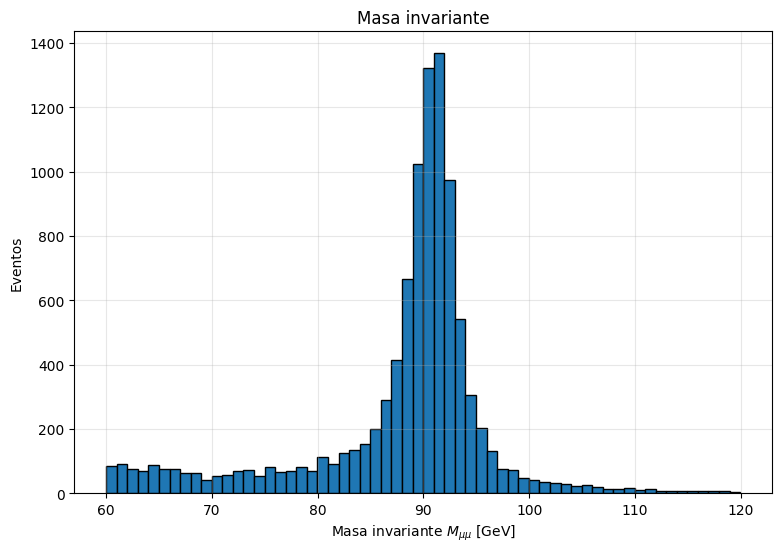

In [11]:
#Histograma de masa
plt.figure(figsize=(9,6))

plt.hist(
    df["M_mumu"],
    bins=60,
    edgecolor="black"
)

plt.xlabel(r"Masa invariante $M_{\mu\mu}$ [GeV]")
plt.ylabel("Eventos")
plt.title("Masa invariante")

plt.grid(alpha=0.3)
plt.show()